## Empirical Parameters
Here I make one figure to justify the use of the empirical parameters in the two layer model. Then another figure to show effect of those parameters.

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize
from matplotlib.lines import Line2D

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.season_annual_harmonic import get_phase_amp
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff, get_temp_from_sphum_sat, get_sensible_heat, \
    get_latent_heat
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic, get_fit_coef_complex
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

from jobs.thesis_season.column.utils import get_flux

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating, \
    get_frierson_sw_abs
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff3

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
from jobs.thesis_season.publish_figs.load import load_ds_all, width, day_seconds
from jobs.thesis_season.publish_figs.energy_budget_empirical import get_approx_flux_atmos, get_empirical_params, \
    get_approx_mse_tend
from jobs.thesis_season.publish_figs.xr_funcs import get_fit_complex_xr, apply_linear_zero_mean_xr, get_fourier_fit_xr

exp_name = 'base'
ds = load_ds_all(exp_name)

Loaded dataset from:
/Users/joshduffield/Documents/StAndrews/Isca/jobs/thesis_season/publish_figs/processed_data/ds_base.nc


In [3]:
def get_error(var, var_approx, time=ds.time, annual_harmonic=False):
    var_fourier, var_amp, _ = get_fourier_fit_xr(time, var, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)
    var_amp = var_amp.sel(harmonic=1)
    if annual_harmonic:
        var_approx_fourier = get_fourier_fit_xr(time, var_approx, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)[0]
        return np.abs(var_fourier - var_approx_fourier).mean(dim='time') / var_amp * 100
    else:
        # Get error relative to annual harmonic amplitude
        return np.abs(var-var_approx).mean(dim='time') / var_amp * 100
        # return (np.abs(var - var_approx) > 0.25 * var_amp).sum(
        #     dim='time') / ds.time.size * 100  # amount of days with large error

### Surface Fluxes
Here I record the error in various approximations in the surface fluxes involved in both the surface and atmospheric energy budget.


In [4]:
def update_args(args_base, params, arg_names):
    args_use = args_base.copy()
    for key in arg_names:
        if key in params:
            args_use[key] = params[key]
    return args_use

In [5]:
var = ds.flux_lhe + ds.flux_t + ds.lwup_sfc - ds.lwdn_sfc
energy_budget_terms = {'surf_flux': {'simulated': var - var.mean(dim='time')}}
energy_budget_error = {'surf_flux': {}}

In [6]:
args_names_atmos = list(inspect.signature(get_approx_flux_atmos).parameters.keys())
args_base_atmos = {key: ds[key] for key in args_names_atmos if key in ds}
args_base_atmos[
    'sw_abs'] = None  # get rid of SW component of RHS of fluxes, as not interested in approximation of this term

# Get error with just surface temperature
lambda_s = get_fit_complex_xr(ds.temp_surf - ds.temp_atm, energy_budget_terms['surf_flux']['simulated'])[0]
key = 'lambda_empirical'
energy_budget_terms['surf_flux'][key] = apply_linear_zero_mean_xr(ds.temp_surf - ds.temp_atm, lambda_s)
energy_budget_error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'],
                                                  energy_budget_terms['surf_flux'][key])

param_order = ['lambda_const', 'lambda_a', 'coef_phase_a']
include_params = []
for key in param_order:
    include_params.append(key)
    if key == 'lambda_const':
        continue
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = get_empirical_params(ds, include_params=include_params)
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    if key == 'lambda_a':
        # sanity check sum equals direct method
        var_direct = feedback_params_use['lambda_a']
        var_sum = feedback_params_use['lambda_a_lh'] + feedback_params_use['lambda_a_lw'] - feedback_params_use[
            'lambda_a_sh']
        xr.testing.assert_allclose(var_direct, var_sum, rtol=1e-5, atol=1e-9)
    energy_budget_terms['surf_flux'][key] = get_approx_flux_atmos(**args_use)
    energy_budget_error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'],
                                                      energy_budget_terms['surf_flux'][key])

style_error = {'surf_flux': {'lambda_empirical': ['Basic fit', '-'],
                             'lambda_a': ['Magnitude', '--'],
                             'coef_phase_a': ['Phase', ':']}}

#### Sanity check plot

Below I plot the simulated and fitted surface fluxes. In the annual harmonic, the best fitting procedure with `coef_phase_a` should exactly match the simulated.

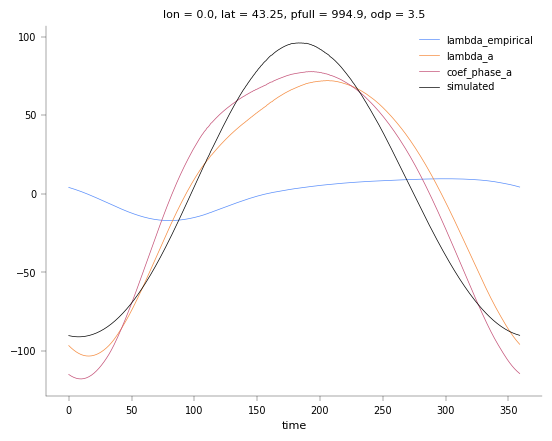

In [7]:
def plot_budget_term(key, key2='surf_flux', plot_annual_harmonic=False, odp_ind=-1):
    data = energy_budget_terms[key2][key].isel(odp=odp_ind)
    if plot_annual_harmonic:
        data = get_fourier_fit_xr(
            ds.time, data, n_harmonics=1, pad_coefs_phase=True, pos_amp=True
        )[0]
    return data.plot(**({'color': 'k'} if key == 'simulated' else {}), label=key)


keys = ['lambda_empirical', 'lambda_a', 'coef_phase_a', 'simulated']
for key in keys:
    plot_budget_term(key, key2='surf_flux', plot_annual_harmonic=False)
plt.legend()

### OLR

For simplicity, I neglect the surface contribution to OLR and assume it all arises from the atmosphere.

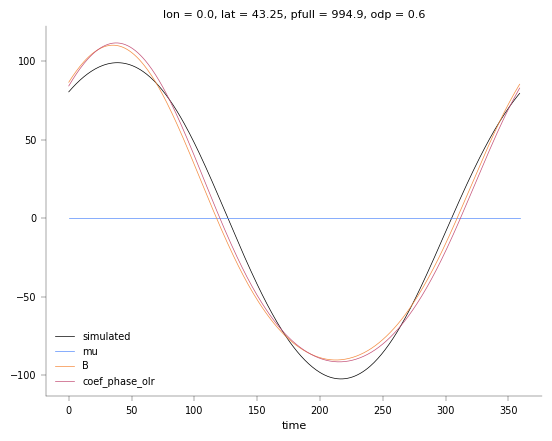

In [8]:
show_plot = True
key2 = 'olr'
var = -ds.olr
energy_budget_terms[key2] = {'simulated': var - var.mean(dim='time')}
energy_budget_error[key2] = {}

# Neglect any surface OLR for simplicity
param_order = ['mu', 'B', 'coef_phase_olr']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = get_empirical_params(ds, include_params=include_params)
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    energy_budget_terms[key2][key] = get_approx_flux_atmos(**args_use)
    energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

style_error[key2] = {'mu': [r'No fit', '-'],
                     'B': [r'Magnitude', '--'],
                     'coef_phase_olr': [r'Phase', ':']}

if show_plot:
    for key in energy_budget_terms['olr']:
        plot_budget_term(key, key2='olr', plot_annual_harmonic=False, odp_ind=0)
        plt.legend()


### Advection
Same as above but for meridional advective component of the atmospheric flux convergence.

In [9]:
show_plot = True
if exp_name == 'advect':
    key2 = 'advect'
    var = ds.adv_atmos
    energy_budget_terms[key2] = {'simulated': var - var.mean(dim='time')}
    energy_budget_error[key2] = {}

    # Neglect any surface OLR for simplicity
    param_order = ['mu', 'lambda_adv', 'coef_phase_adv']
    include_params = []
    for key in param_order:
        include_params.append(key)
        # Only use empirical lambda_const if lambda_a not included
        feedback_params_use = get_empirical_params(ds, include_params=include_params)
        args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
        energy_budget_terms[key2][key] = get_approx_flux_atmos(**args_use)
        energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'],
                                                   energy_budget_terms[key2][key])

    style_error[key2] = {'mu': [r'No fit', '-'],
                     'lambda_adv': [r'Magnitude', '--'],
                     'coef_phase_adv': [r'Phase', ':']}

    if show_plot:
        for key in energy_budget_terms[key2]:
            plot_budget_term(key, key2=key2, plot_annual_harmonic=False)
            plt.legend()

### MSE Tendency - Dry

Below I compute and plot the column weighted average temperature component of the MSE tendency.

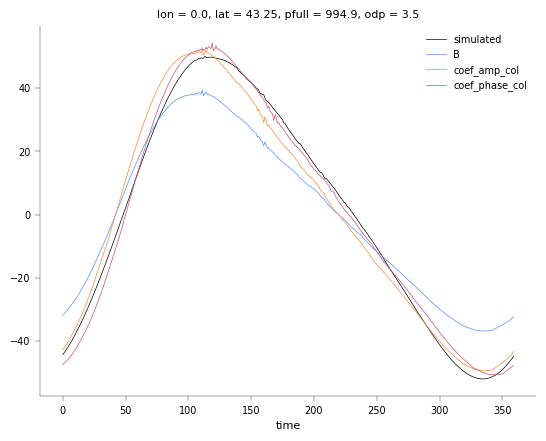

In [10]:
show_plot = True
key2 = 'mse_tend_dry'
var = ds.mse_tend_atmos - ds.sphum_col_tend * L_v
energy_budget_terms[key2] = {'simulated': var - var.mean(dim='time')}
energy_budget_error[key2] = {}

param_order = ['B', 'coef_amp_col', 'coef_phase_col']  # B is the check where \beta=1
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = get_empirical_params(ds, include_params=include_params)
    energy_budget_terms[key2][key] = get_approx_mse_tend(ds.temp_atm, feedback_params_use['coef_amp_col'],
                                                         feedback_params_use['coef_phase_col'],
                                                         feedback_params_use['mu'],
                                                         feedback_params_use['coef_phase_mu'],
                                                         ds.p_integ_calc.mean(dim='time'), ds.time)
    energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

    style_error[key2] = {'B': [r'No fit', '-'],
                 'coef_amp_col': [r'Magnitude', '--'],
                 'coef_phase_col': [r'Phase', ':']}

if show_plot:
    for key in energy_budget_terms[key2]:
        plot_budget_term(key, key2=key2, plot_annual_harmonic=False)
    plt.legend()

### MSE Tendency - Moist
Here I compute the column specific humidity tendency component of the MSE tendency.

We see a notable error here, because we are approximating $dq_{col}/dt$ as $\mu dT_a/dt$, but really it should be $\mu (T_a-\overline{T}_a)dT_a/dt$ because of nonlinear clausius clapeyron effect. This effect causes $dq_{col}/dt$ to have significant second harmonic hence the error seen is very notable for the all harmonic error, but is still present for annual harmonic, as in the approximation we are taking the annual harmonic of $\mu dT_a/dt$ not $\mu (T_a-\overline{T}_a)dT_a/dt$, which are slightly different.


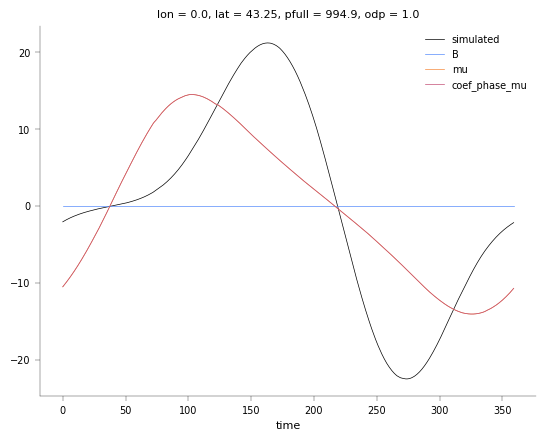

In [11]:
show_plot = True
key2 = 'mse_tend_moist'
var = ds.sphum_col_tend * L_v
energy_budget_terms[key2] = {'simulated': var - var.mean(dim='time')}
energy_budget_error[key2] = {}

param_order = ['B', 'mu', 'coef_phase_mu']  # B is the check where \mu=0
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = get_empirical_params(ds, include_params=include_params)
    feedback_params_use['coef_amp_col'] = feedback_params_use['coef_amp_col'] * 0
    energy_budget_terms[key2][key] = get_approx_mse_tend(ds.temp_atm, feedback_params_use['coef_amp_col'],
                                                         feedback_params_use['coef_phase_col'],
                                                         feedback_params_use['mu'],
                                                         feedback_params_use['coef_phase_mu'],
                                                         ds.p_integ_calc.mean(dim='time'), ds.time)
    energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

    style_error[key2] = {'B': [r'No fit', '-'],
             'mu': [r'Magnitude', '--'],
             'coef_phase_mu': [r'Phase', ':']}

if show_plot:
    for key in energy_budget_terms[key2]:
        plot_budget_term(key, key2=key2, plot_annual_harmonic=False, odp_ind=2)
    plt.legend()

### Paper figure
Plot the error as more parameters added to the approximation. These errors are in terms of all harmonics, as pretty trivial with annual harmonic that can get perfect fit.

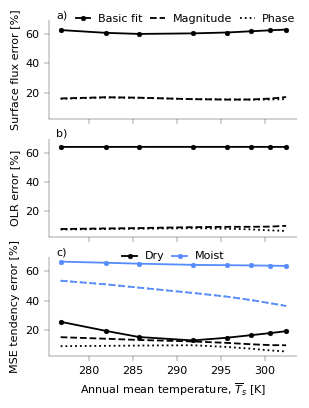

In [12]:
markersize = 7
x_var = ds.temp_surf.mean(dim='time')
fig, ax = plt.subplots(3, 1, sharey=True, sharex=True)
fig_resize(fig, width['one_col']*1, 2.2)

# Surface fluxes
key = 'surf_flux'
for key2 in style_error[key]:
    ax[0].plot(x_var, energy_budget_error[key][key2], color='k', label=style_error[key][key2][0],
               linestyle=style_error[key][key2][1], marker='.' if style_error[key][key2][1]=='-' else None, markersize=markersize)

key = 'olr'
for key2 in style_error[key]:
    ax[1].plot(x_var, energy_budget_error[key][key2], color='k', label=style_error[key][key2][0],
               linestyle=style_error[key][key2][1], marker='.' if style_error[key][key2][1]=='-' else None, markersize=markersize)

if exp_name == 'advect':
    key = 'advect'
    for key2 in style_error[key]:
        ax[1].plot(x_var, energy_budget_error[key][key2], color='C0',
                   linestyle=style_error[key][key2][1], marker='.' if style_error[key][key2][1]=='-' else None, markersize=markersize)

for i, key in enumerate(['mse_tend_dry', 'mse_tend_moist']):
    for key2 in style_error[key]:
            ax[2].plot(x_var, energy_budget_error[key][key2], color=['k', 'C0'][i],
                       linestyle=style_error[key][key2][1],
                       marker='.' if style_error[key][key2][1]=='-' else None, markersize=markersize)


update_linewidth(fig, 1.3)
ax[0].legend(ncol=3, columnspacing=0.8, handlelength=1.5, loc='upper center', bbox_to_anchor=(0.55, 1.15))

# Keep the existing linestyle legend on the middle plot
# style_legend = ax[1].legend(
#     ncol=3, columnspacing=0.8, handlelength=1.5, loc='center left')
# ax[1].add_artist(style_legend)

# Add colour legends to the bottom two plots, using existing solid lines
for i, a in enumerate(ax[1:]):
    if (exp_name != 'advect') and i==0:
        continue
    handles = []
    labels = []

    for color, label in [('k', ['OLR', 'Dry']), ('C0', ['Advection', 'Moist'])]:
        line = next(
            (line for line in a.get_lines()
             if line.get_linestyle() == '-' and line.get_color() == color),
            None,
        )
        if line is not None:
            handles.append(line)
            labels.append(label[i])

    a.legend(
        handles=handles,
        labels=labels,
        ncol=2,
        columnspacing=0.8,
        handlelength=1.5,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
    )

ax[0].set_ylabel('Surface flux error [%]')
ax[1].set_ylabel('OLR error [%]')
ax[2].set_ylabel('MSE tendency error [%]')
ax[-1].set_xlabel(r'Annual mean temperature, $\overline{T}_s$ [K]')
label_subplots(fig, ax, pos_y=7, box_alpha=0)
update_fontsize(fig)
plt.show()
# savefig(fig)

### Effect of parameters on $\lambda_{eff}$, $C_{eff}$, phase and gain

Note that gain is amplitude relative to amplitude of net SW radiation at surface i.e., $(1-f)(1-\alpha) SW_{TOA}$. I choose the order to make clearer but pretty arbitary. But role of each parameter depends on order, as sensitivity is altered as more parameters are added.

In [13]:
param_order = ['lambda_const', 'B', 'coef_phase_olr', 'lambda_a', 'coef_phase_a', 'lambda_adv', 'coef_phase_adv', 'mu', 'sw_abs', 'coef_amp_col']
# param_order = [key for key in param_order if 'phase' not in key]
if exp_name != 'advect':
    exclude_params = ['lambda_adv', 'coef_phase_adv']
    param_order[:] = [key for key in param_order if ('adv' not in key) and ('phase' not in key)]
    param_order += ['coef_phase_col']
else:
    exclude_params = None
feedback_params = get_empirical_params(ds, exclude_params=exclude_params)


def get_phase_info(params, non_zero_params, heat_cap_surf=ds.heat_cap_surf,
                   pressure_heat_cap_atmos_calc=ds.p_integ_calc.mean(dim='time'),
                   sw_abs=ds.sw_abs, albedo=ds.albedo, coef_sw_amp=ds.coef_sw_amp, omega=ds.omega):
    arg_names = list(inspect.signature(get_heat_cap_lambda_eff3).parameters.keys())
    arg_use = {key: params[key] for key in arg_names if key in params}
    for key in arg_use:
        if (key == 'coef_amp_col') and (key not in non_zero_params):
            arg_use[key] = arg_use[key] * 0 + 1
        elif key not in non_zero_params:
            arg_use[key] = arg_use[key] * 0
    arg_use['heat_cap_surf'] = heat_cap_surf
    arg_use['pressure_heat_cap_atmos_calc'] = pressure_heat_cap_atmos_calc
    arg_use['sw_abs'] = sw_abs if 'sw_abs' in non_zero_params else 0
    arg_use['albedo'] = albedo
    arg_use['lambda_lw'] = 0

    lambda_eff, heat_cap_eff = get_heat_cap_lambda_eff3(**arg_use, small_phase=False, simple_phase_a=True)
    phase, amp = get_phase_amp(coef_sw_amp, omega, heat_cap_eff, lambda_eff)
    return heat_cap_eff / heat_cap_surf, lambda_eff, phase / omega / day_seconds, amp / coef_sw_amp


heat_cap_eff = {}
lambda_eff = {}
phase = {}
gain = {}
for i, key in enumerate(param_order):
    heat_cap_eff[key], lambda_eff[key], phase[key], gain[key] = get_phase_info(feedback_params, param_order[:i + 1])

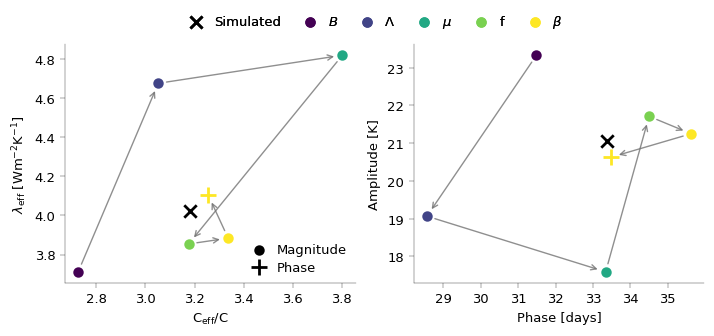

In [15]:
# Explicitly group phase terms with their corresponding non-phase term.
# Entries without a counterpart retain their own colour group.
energy_budget_labels = {'lambda_const': r'$\lambda$', 'lambda_a': r'$\Lambda$',
                        'coef_phase_a': r'$\phi_{\Lambda}$', 'B': '$B$',
                        'lambda_adv': r'$B_{\text{adv}}$', 'coef_phase_adv': r'$\phi_{\text{adv}}$',
                        'coef_phase_olr': r'$\phi_{B}$', 'coef_amp_col': r'$\beta$',
                        'mu': r"$\mu$", 'coef_phase_col': r'$\phi_{\beta}$', 'sw_abs': r'$\mathrm{f}$'}

odp_plot = 1.5
no_phase_plot = False  # If True, will only show one symbol (combined phase and amplitude effect for each symbol)
show_gain = False  # Whether to show the gain or the amplitude

colour_group = {
    'B': 'B',
    'coef_phase_olr': 'B',
    'lambda_a': 'a',
    'coef_phase_a': 'a',
    'lambda_adv': 'adv',
    'coef_phase_adv': 'adv',
    'mu': 'mu',
    'sw_abs': 'sw_abs',
    'coef_amp_col': 'col',
    'coef_phase_col': 'col',
}

# Sequential colours, one per unique model/component group
groups = list(dict.fromkeys(colour_group[k] for k in colour_group))
cmap = plt.colormaps["viridis"]
colours = {
    group: cmap(i / max(len(groups) - 1, 1))
    for i, group in enumerate(groups)
}

if exp_name != 'advect':
    colour_group = {key: colour_group[key] for key in colour_group if 'adv' not in key}
if ds.atm_abs == 0:
    del colour_group['sw_abs']

if no_phase_plot:
    # for simple plot only show 1 symbol (the best one for each
    del colour_group['B'], colour_group['lambda_a'], colour_group['lambda_adv'], colour_group['coef_phase_col']

fig, ax = plt.subplots(1, 2)
fig_resize(fig, width['two_col'] * 1.5)

ax[0].set_xlabel(r"C$_{\text{eff}}/$C")
ax[0].set_ylabel(r"$\lambda_{\text{eff}}$ [Wm$^{-2}\text{K}^{-1}$]")
ax[1].set_xlabel("Phase [days]")
ax[1].set_ylabel('Gain [KW$^{-1}$m$^2$]' if show_gain else 'Amplitude [K]')

# Store positions so arrows can be drawn after plotting
left_xy = []
right_xy = []

for i, key in enumerate(colour_group):
    if key not in heat_cap_eff:
        continue
    # if i>4:
    #     continue
    marker = "." if no_phase_plot else ("+" if "phase" in key else ".")
    colour = colours[colour_group[key]]

    x0, y0 = heat_cap_eff[key].sel(odp=odp_plot), lambda_eff[key].sel(odp=odp_plot)
    x1, y1 = phase[key].sel(odp=odp_plot), gain[key].sel(odp=odp_plot) if show_gain else (gain[key] * ds.coef_sw_amp).sel(odp=odp_plot)

    ax[0].plot(
        x0, y0, marker=marker, linestyle="None",
        color=colour, markersize=11, markeredgewidth=2,
        label=key
    )
    ax[1].plot(
        x1, y1, marker=marker, linestyle="None",
        color=colour, markersize=11, markeredgewidth=2,
        label=key
    )

    left_xy.append((x0, y0))
    right_xy.append((x1, y1))

# Directional arrows: progression follows the order in `keys`
for axis, points in zip(ax, [left_xy, right_xy]):
    for start, end in zip(points[:-1], points[1:]):
        axis.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                color="0.45",
                lw=1.0,
                shrinkA=6,
                shrinkB=6,
                alpha=0.8,
            ),
            zorder=0,
        )
ax[0].scatter((ds.heat_cap_eff / ds.heat_cap_surf).sel(odp=odp_plot), ds.lambda_eff.sel(odp=odp_plot),
              color='k', marker='x', s=80, lw=2, zorder=50)

phase_use, amp_use = get_phase_amp(ds.coef_sw_amp.sel(odp=odp_plot), ds.omega, ds.heat_cap_eff.sel(odp=odp_plot),
                                   ds.lambda_eff.sel(odp=odp_plot))
ax[1].scatter(phase_use / ds.omega / day_seconds, amp_use / ds.coef_sw_amp.sel(odp=odp_plot) if show_gain else amp_use,
              color='k', marker='x', s=80, lw=2, zorder=50)

# In the plotting loop: remove `label=key` from both ax[0].plot and ax[1].plot
# (or use label="_nolegend_")

# Colour legend: include only the non-phase variables
non_phase_keys = colour_group if no_phase_plot else [key for key in colour_group if "phase" not in key]
labels_use = energy_budget_labels.copy()
if no_phase_plot:
    labels_use['coef_phase_olr'] = '$B$'
    labels_use['coef_phase_a'] = r'$\lambda_a$'
    labels_use['coef_phase_adv'] = r'$\lambda_{\text{adv}}$'
    labels_use['coef_phase_col'] = r'$\beta_{\text{col}}$'

colour_handles = [
    Line2D(
        [0], [0],
        marker=".",
        linestyle="None",
        color=colours[colour_group[key]],
        markersize=11,
        markeredgewidth=2,
        label=labels_use[key],
    )
    for key in non_phase_keys
]
colour_handles = [Line2D(
    [0], [0],
    marker="x",
    linestyle="None",
    color='k',
    markersize=8,
    markeredgewidth=2,
    label='Simulated',
)] + colour_handles

# Marker/style legend: explains the role of phase terms
phase_handles = [
    Line2D(
        [0], [0],
        marker=".",
        linestyle="None",
        color="k",
        markersize=11,
        markeredgewidth=2,
        label="Magnitude",
    ),
    Line2D(
        [0], [0],
        marker="+",
        linestyle="None",
        color="k",
        markersize=11,
        markeredgewidth=2,
        label="Phase",
    ),
]

# Keep both legends by adding the first one back as an artist
# legend_colours = ax[0].legend(
#     handles=colour_handles,
#     loc="upper left",
#     frameon=False, ncol=2
# )
legend_colours = fig.legend(
    handles=colour_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    frameon=False,
    ncol=len(colour_handles),
)

ax[0].add_artist(legend_colours)

if not no_phase_plot:
    legend_markers = ax[0].legend(
        handles=phase_handles,
        loc="lower right",
        frameon=False,
    )
update_fontsize(fig)
# if 'column' not in exp_dir:
#     ax[0].set_xlim(2.35, 4.3)
#     ax[0].set_ylim(3.05, 5.2)
#     ax[1].set_xlim(25, 38.5)
#     if show_gain:
#         ax[1].set_ylim(0.16, 0.26)
#     else:
#         ax[1].set_ylim(15.5, 26)
plt.show()
# savefig(fig)